Insertion sort vs Merge sort vs Quick sort on SMALL lists. We will show specific cases where Insertion sort does better than the other two, as well as cases where it is most definitely worse.

In [5]:
from auxilary.bad_sorts import create_random_list, create_near_sorted_list, insertion_sort
from auxilary.good_sorts import mergesort, quicksort
import matplotlib.pyplot as plt
import timeit
import gc
from collections import defaultdict

In [2]:
def random_reverse_sorted_list(max_value):
    return list(range(max_value, 0, -1))

# we use this function to check insertion sort's best case
def count_inversions(L):
    # An inversion is a pair of indices (i, j) such that i < j but L[i] > L[j].
    # This directly correlates to how many "swaps" insertion sort must do.
    count = 0
    n = len(L)
    for i in range(n):
        for j in range(i + 1, n):
            if L[i] > L[j]:
                count += 1
    return count

# sort the information we get from counting out of place 
def sort_results(x_vals, y_vals):
    zipped = sorted(zip(x_vals, y_vals))
    x_sorted, y_sorted = zip(*zipped)
    return list(x_sorted), list(y_sorted)

In [ ]:
# intiialise lists of fixed lengths for now
# Create a list of lengths from 0 - 150 stepping by 3
lengths = list(range(0, 150, 3))
lists = [create_random_list(l, 10000) for l in lengths]

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []
# tests per list, take the best occurence
trials = 1000
for i in range(n):
    
    best = float('inf')
    gc.disable()
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append(best)
    gc.enable()

plt.plot(lengths, insertion_times, color='red')
plt.plot(lengths, mergesort_times, color='blue')
plt.plot(lengths, quicksort_times, color='green')
plt.legend(['insertion sort', 'mergesort', 'quicksort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of insertion sort vs mergesort vs quicksort for random lists of length 0 to 150')
plt.show()

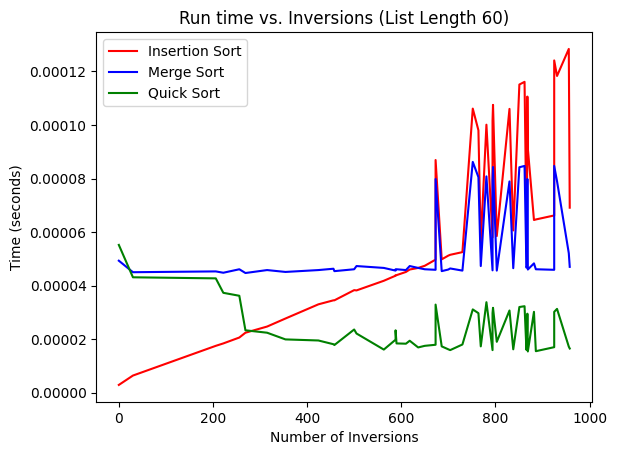

In [ ]:
# lists of length 60, with 0-60 swaps
# note that ebven for a list of length 150, having 10/150 swaps is quite similar for insertion sort
# as 10/60 swaps for a list of length 60. However the likelihood is much less, so we test w length 60
max_length = 60
swaps = list(range(0, 100, 2))
lists = [create_near_sorted_list(max_length, 5000, s) for s in swaps]

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []

# new x axis for inver elements
inversion_x_axis = []
# tests per list, take the best occurence
trials = 2000

for i in range(n):
    inv_count = count_inversions(lists[i])
    inversion_x_axis.append(inv_count)

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append(best)
    gc.enable()
    
final_x, final_ins = sort_results(inversion_x_axis, insertion_times)
_, final_merge = sort_results(inversion_x_axis, mergesort_times)
_, final_quick = sort_results(inversion_x_axis, quicksort_times)


plt.plot(final_x, final_ins, color='red', label='Insertion Sort')
plt.plot(final_x, final_merge, color='blue', label='Merge Sort')
plt.plot(final_x, final_quick, color='green', label='Quick Sort')
plt.legend()
plt.xlabel('Number of Inversions')
plt.ylabel('Time (seconds)')
plt.title('Run time vs. Inversions (List Length 60)')
plt.show()

In [ ]:
# random reversed lists only
lengths = list(range(0, 60, 1))
lists = [random_reverse_sorted_list(l) for l in lengths]

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []
# tests per list, take the best occurence
trials = 5000
for i in range(n):
    
    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append(best)
    gc.enable()

    gc.disable()
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append(best)
    gc.enable()
    

plt.plot(lengths, insertion_times, color='red')
plt.plot(lengths, mergesort_times, color='blue')
plt.plot(lengths, quicksort_times, color='green')
plt.legend(['insertion sort', 'mergesort', 'quicksort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of insertion sort vs mergesort vs quicksort for reverse sorted lists of length 0 to 60')
plt.show()